# 01 — Data Understanding

## Project: Sales Anomaly Detection for a Multi-Outlet F&B Business

### Objective

The goal of this project is to build an end-to-end anomaly detection pipeline for real Food and Beverage point-of-sale transaction data.

The project focuses on detecting abnormal business patterns such as:

- Unexpected sales spikes
- Unexpected sales drops
- Product-level demand anomalies
- Category-level sales anomalies
- Outlet-level abnormal sales behavior
- Transaction-level anomalies
- Data quality issues in sales records

### Dataset

The dataset used in this project is the Anonymous Transactional Dataset from Mendeley Data.

It contains real-world historical sales transactions and product metadata from a local Food and Beverage MSME operating multiple outlets in Indonesia.

The dataset includes two main files:

- Transactions.csv
- Products.csv

### Purpose of this notebook

This notebook focuses on understanding the raw dataset before any cleaning, feature engineering, or anomaly detection.

We will inspect:

- Dataset shape
- Column names
- Data types
- Missing values
- Date range
- Product coverage
- Transaction granularity
- Basic sales distributions
- Initial data quality concerns

# Step 1 — Project and Dataset Documentation

## What we are doing

In this step, we are documenting the project context before starting any technical analysis.

The project will use a real Food and Beverage transactional dataset to build an end-to-end anomaly detection pipeline. The dataset contains historical point-of-sale sales transactions and product metadata from a local F&B business operating multiple outlets.

The main goal is to understand whether abnormal sales patterns can be detected across transactions, products, categories, and outlets.

---

## Why we are doing this

Before writing code or building models, it is important to clearly define:

- The business problem
- The dataset being used
- The expected anomaly types
- The scope and limitations of the project
- The purpose of the first notebook

This helps make the project easier to understand, easier to present, and easier to extend later.

In real business projects, anomaly detection is not only a modeling problem. It also requires understanding the business context behind the data, such as products, outlets, sales behavior, and possible data quality issues.

---

## Project title

**Sales Anomaly Detection for a Multi-Outlet F&B Business**

---

## Dataset source

The dataset used in this project is:

**Anonymous Transactional Dataset — Mendeley Data**

The dataset contains real-world historical sales transactions and product metadata collected from a local Food and Beverage Micro-Small-Medium Enterprise operating multiple outlets in Indonesia.

The transaction records were collected from the business's internal Point-of-Sale system between January 2025 and September 2025.

The dataset includes two main CSV files:

- `Transactions.csv`
- `Products.csv`

---

## Business objective

The objective of this project is to detect unusual sales behavior in F&B transaction data.

The project focuses on identifying patterns such as:

- Unexpected sales spikes
- Unexpected sales drops
- Product-level demand anomalies
- Category-level sales anomalies
- Outlet-level abnormal sales behavior
- Transaction-level anomalies
- Data quality issues in sales records

---

## Machine learning problem type

This project will be treated as an **unsupervised anomaly detection** problem.

This is because the dataset does not provide confirmed anomaly labels. Therefore, anomalies will need to be identified using:

- Business rules
- Statistical thresholds
- Time-based comparisons
- Unsupervised anomaly detection models
- Business interpretation of flagged records

The goal is not only to flag unusual records, but also to explain why they may be important from a business perspective.

---

## Expected analysis levels

The project may analyze anomalies at different business levels:

### 1. Transaction level

Examples:

- Very high transaction value
- Very low or zero transaction value
- Unusual quantity sold
- Inconsistent totals
- Possible duplicate transactions

### 2. Product level

Examples:

- Sudden increase in demand for a product
- Sudden drop in demand for a product
- Product sales that behave differently from similar products

### 3. Category level

Examples:

- Category sales spike
- Category sales drop
- Category contribution changing unexpectedly

### 4. Outlet level

Examples:

- One outlet has unusually high sales
- One outlet has unusually low sales
- One outlet behaves differently compared to others

### 5. Time level

Examples:

- Abnormal daily sales
- Abnormal weekly sales
- Unusual sales behavior by hour, day, or month if time information is available

---

## Known limitations before inspection

Before inspecting the files, some expected limitations should be noted:

- The dataset may not contain customer-level information.
- The dataset may not contain inventory or stock levels.
- The dataset may not contain usable discount, refund, event, or staff information.
- The dataset may not include official anomaly labels.
- Some anomaly types, such as stockout-related drops, may not be directly provable without inventory data.

These limitations will be confirmed during the data understanding phase.

---

## Purpose of this notebook

This notebook is called:

`01_data_understanding.ipynb`

The purpose of this notebook is to inspect and understand the raw dataset before any cleaning, feature engineering, or modeling.

In this notebook, we will inspect:

- Dataset shape
- Column names
- Data types
- Missing values
- Date range
- Transaction granularity
- Product coverage
- Category coverage
- Outlet coverage
- Basic numeric summaries
- Initial data quality issues

---

## Expected outcome of this step

By the end of the data understanding notebook, we should be able to answer:

1. What does each row represent?
2. What columns are available?
3. Which columns are useful for anomaly detection?
4. What is the time period covered by the data?
5. What are the main business entities in the dataset?
6. Are there missing or suspicious values?
7. What anomaly types are realistic for this dataset?
8. Is the dataset suitable for the full anomaly detection project?

---

## Next step

After documenting the project context, the next step is to import the required Python libraries and load the two raw CSV files:

- `Transactions.csv`
- `Products.csv`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
transactions_path = "../data/raw/Transactions.csv"
products_path = "../data/raw/Products.csv"

transactions = pd.read_csv(transactions_path)
products = pd.read_csv(products_path)

display(transactions.head())
display(products.head())

,Outlet,Date,Time,NetSales,Tax,TotalAmount,ReceiptNumber,Items,TotalItem,PaymentMethod,UseLoyaltyCard
0,SHOP001,2025-01-02,07:01:05,20720.721,2279.279,23000,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0
1,SHOP001,2025-01-02,07:04:11,18018.018,1981.982,20000,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0
2,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0
3,SHOP002,2025-01-02,07:14:25,36036.036,3963.964,40000,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0
4,SHOP002,2025-01-02,07:23:05,36036.036,3963.964,40000,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0


,ProductId,ProductName,Variant,Category,Price,Description
0,1,Add on Aren,-,Add on,0,"Tambahan sirup gula aren murni, memberikan ras..."
1,2,Add on Simple Syrup,-,Add on,0,Tambahan sirup gula sederhana (air dan gula) s...
2,3,Air Mineral,-,Other,5000,Air minum murni dalam kemasan
3,4,Americano,Hot Houseblend,Coffee,20000,Minuman kopi hitam yang dibuat dengan menambah...
4,5,Americano,Ice Houesblend,Coffee,20000,Minuman kopi hitam yang dibuat dengan menambah...


In [3]:
print("Transactions shape:", transactions.shape)
print("Products shape:", products.shape)

print("\nTransactions info:")
transactions.info()

print("\nProducts info:")
products.info()

Transactions shape: (53820, 11)
Products shape: (96, 6)

Transactions info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53820 entries, 0 to 53819
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Outlet          53820 non-null  object 
 1   Date            53820 non-null  object 
 2   Time            53820 non-null  object 
 3   NetSales        53820 non-null  float64
 4   Tax             53820 non-null  float64
 5   TotalAmount     53820 non-null  int64  
 6   ReceiptNumber   53820 non-null  object 
 7   Items           53820 non-null  object 
 8   TotalItem       53820 non-null  int64  
 9   PaymentMethod   53820 non-null  object 
 10  UseLoyaltyCard  53820 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 4.5+ MB

Products info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ----

In [4]:
print("Transactions columns:")
print(transactions.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

Transactions columns:
['Outlet', 'Date', 'Time', 'NetSales', 'Tax', 'TotalAmount', 'ReceiptNumber', 'Items', 'TotalItem', 'PaymentMethod', 'UseLoyaltyCard']

Products columns:
['ProductId', 'ProductName', 'Variant', 'Category', 'Price', 'Description']



### What we are doing

In this step, we standardize column names in both datasets and investigate what each row represents in the transactions dataset.

We also analyze the `receipt_number` and `items` column to determine the dataset's granularity.

### Why we are doing this

Standardizing column names improves readability and avoids inconsistencies in later steps.

Understanding granularity is critical for anomaly detection because it determines:

- Whether we are working at the transaction level or product level
- What types of anomalies we can detect
- Whether we need to transform or expand the dataset

### What we expect to find

We want to determine:

- Whether each row represents one receipt (transaction-level)
- Whether product-level details are available directly or embedded in the `items` column
- Whether data transformation will be needed before feature engineering


In [5]:
# Standardize column names
transactions.columns = (
    transactions.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

products.columns = (
    products.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Fix concatenated words manually
transactions = transactions.rename(columns={
    "netsales": "net_sales",
    "totalamount": "total_amount",
    "receiptnumber": "receipt_number",
    "totalitem": "total_item",
    "paymentmethod": "payment_method",
    "useloyaltycard": "use_loyalty_card"
})

products = products.rename(columns={
    "productid": "product_id",
    "productname": "product_name"
})

print("Transactions columns:", transactions.columns.tolist())
print("Products columns:", products.columns.tolist())


Transactions columns: ['outlet', 'date', 'time', 'net_sales', 'tax', 'total_amount', 'receipt_number', 'items', 'total_item', 'payment_method', 'use_loyalty_card']
Products columns: ['product_id', 'product_name', 'variant', 'category', 'price', 'description']


In [6]:
# Preview data
transactions.head()


,outlet,date,time,net_sales,tax,total_amount,receipt_number,items,total_item,payment_method,use_loyalty_card
0,SHOP001,2025-01-02,07:01:05,20720.721,2279.279,23000,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0
1,SHOP001,2025-01-02,07:04:11,18018.018,1981.982,20000,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0
2,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0
3,SHOP002,2025-01-02,07:14:25,36036.036,3963.964,40000,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0
4,SHOP002,2025-01-02,07:23:05,36036.036,3963.964,40000,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0


In [7]:
# Inspect items column
transactions["items"].head(10).tolist()


['Basic Latte (Ice Arabica)',
 'BLACK (Houseblend)',
 'Friendly Coffee (Hot), Shakencano',
 'BLACK (Arabica), Americano (Hot Arabica)',
 'WHITE (Arabica), Susu Oat',
 'Americano (Hot Houseblend)',
 'Banana Bread (Chocolate)',
 'Not Tiramisu Latte (Gedhe)',
 'Espresso Arabica (On The Rock)',
 'Jasmine (Hot)']

In [8]:
print("Rows:", len(transactions))

print("Unique receipts:", transactions["receipt_number"].nunique())


Rows: 53820
Unique receipts: 53820


## The dataset is a transaction-level dataset with product details embedded in the `items` column. Each row represents a single receipt, and the `items` column contains a list of products sold in that transaction.

## Date and Time Processing

### What we are doing

In this step, we convert the `date` and `time` columns into proper datetime formats and create time-based features.

These features will help us analyze transaction behavior across:

- Hours
- Days
- Weekdays
- Months
- Time periods

### Why we are doing this

Sales anomaly detection is strongly dependent on time patterns.

For example:

- unusually high sales during certain hours,
- unexpected drops during business hours,
- abnormal weekend behavior,
- unusual outlet activity,
- sudden spikes during specific dates.

To analyze these behaviors correctly, we need structured datetime features.

### Expected outcome

By the end of this step, we will have:

- A proper transaction timestamp
- Extracted hour/day/month features
- A better understanding of the dataset's time coverage
- A foundation for time-series anomaly analysis

In [9]:
# Convert date column
transactions["date"] = pd.to_datetime(transactions["date"])

# Combine date and time into one timestamp
transactions["transaction_datetime"] = pd.to_datetime(
    transactions["date"].astype(str) + " " + transactions["time"]
)

# Preview
transactions[[
    "date",
    "time",
    "transaction_datetime"
]].head()

,date,time,transaction_datetime
0,2025-01-02,07:01:05,2025-01-02 07:01:05
1,2025-01-02,07:04:11,2025-01-02 07:04:11
2,2025-01-02,07:10:46,2025-01-02 07:10:46
3,2025-01-02,07:14:25,2025-01-02 07:14:25
4,2025-01-02,07:23:05,2025-01-02 07:23:05


In [10]:
# Extract time-based features
transactions["year"] = transactions["transaction_datetime"].dt.year
transactions["month"] = transactions["transaction_datetime"].dt.month
transactions["day"] = transactions["transaction_datetime"].dt.day

transactions["hour"] = transactions["transaction_datetime"].dt.hour
transactions["minute"] = transactions["transaction_datetime"].dt.minute

transactions["day_name"] = transactions["transaction_datetime"].dt.day_name()

transactions["is_weekend"] = transactions["day_name"].isin([
    "Saturday",
    "Sunday"
])

transactions.head()

,outlet,date,time,net_sales,tax,total_amount,receipt_number,items,total_item,payment_method,use_loyalty_card,transaction_datetime,year,month,day,hour,minute,day_name,is_weekend
0,SHOP001,2025-01-02,07:01:05,20720.721,2279.279,23000,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0,2025-01-02 07:01:05,2025,1,2,7,1,Thursday,False
1,SHOP001,2025-01-02,07:04:11,18018.018,1981.982,20000,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0,2025-01-02 07:04:11,2025,1,2,7,4,Thursday,False
2,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0,2025-01-02 07:10:46,2025,1,2,7,10,Thursday,False
3,SHOP002,2025-01-02,07:14:25,36036.036,3963.964,40000,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0,2025-01-02 07:14:25,2025,1,2,7,14,Thursday,False
4,SHOP002,2025-01-02,07:23:05,36036.036,3963.964,40000,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0,2025-01-02 07:23:05,2025,1,2,7,23,Thursday,False


In [11]:
print("Minimum date:", transactions["transaction_datetime"].min())
print("Maximum date:", transactions["transaction_datetime"].max())

Minimum date: 2025-01-02 07:01:05
Maximum date: 2025-09-30 22:56:59


In [12]:
transactions["hour"].value_counts().sort_index()

hour
7     2313
8     2330
9     3376
10    3150
11    3195
12    3258
13    3233
14    3066
15    3160
16    3268
17    3879
18    3857
19    3895
20    3981
21    3887
22    3972
Name: count, dtype: int64

In [13]:
transactions["day_name"].value_counts()

day_name
Sunday       7830
Friday       7829
Thursday     7695
Tuesday      7691
Monday       7642
Saturday     7604
Wednesday    7529
Name: count, dtype: int64

## Findings — Time-Based Transaction Behavior

### Hour-Level Observations

Transaction activity is lower during early morning hours and gradually increases throughout the day.

The highest transaction activity occurs during evening hours, especially between:

- 17:00
- 22:00

This behavior appears realistic for a Food and Beverage business and suggests that customer traffic peaks during evening operating hours.

No transactions were observed outside the approximate operating window of:

- 07:00 to 22:00

This indicates that the dataset does not currently show suspicious overnight transaction activity.

### Day-Level Observations

Transaction counts are relatively balanced across all weekdays.

The busiest days appear to be:

- Sunday
- Friday

This may reflect typical weekend or leisure-driven customer behavior in the F&B industry.

No severe imbalance or missing-day patterns were observed, which suggests that the dataset has relatively stable temporal coverage.

### Implications for anomaly detection

The dataset appears suitable for:

- Hour-level anomaly detection
- Daily sales anomaly detection
- Weekend vs weekday analysis
- Outlet activity monitoring
- Time-series anomaly analysis

## Data Quality and Business Validation Checks

### What we are doing

In this step, we inspect the dataset for data quality issues and business logic inconsistencies.

We validate whether transaction values, taxes, receipt numbers, item counts, and payment information behave as expected.

### Why we are doing this

Not all anomalies are meaningful business anomalies.

Some unusual records may simply result from:

- data entry issues,
- duplicated transactions,
- incorrect calculations,
- missing values,
- inconsistent business logic.

Before building anomaly detection models, we must separate:

- true business anomalies,
from:
- data quality problems.

### What we expect to validate

We will inspect:

- Duplicate receipts
- Missing values
- Negative or zero sales
- Abnormal tax behavior
- Invalid item counts
- Payment method consistency
- Loyalty card usage patterns
- Transaction amount consistency

### Expected outcome

By the end of this step, we should understand:

- whether the dataset is clean enough for modeling,
- which records may require cleaning,
- which unusual patterns are actual business anomalies,
- and which are likely data-quality issues.

In [14]:
missing_summary = pd.DataFrame({
    "missing_count": transactions.isna().sum(),
    "missing_percentage": (
        transactions.isna().mean() * 100
    ).round(2)
})

missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
outlet,0,0.0
use_loyalty_card,0,0.0
day_name,0,0.0
minute,0,0.0
hour,0,0.0
day,0,0.0
month,0,0.0
year,0,0.0
transaction_datetime,0,0.0
payment_method,0,0.0


In [15]:
duplicate_receipts = transactions[
    transactions.duplicated(
        subset=["receipt_number"],
        keep=False
    )
]

print("Duplicate receipt rows:", len(duplicate_receipts))


Duplicate receipt rows: 0


In [16]:
checks = {
    "zero_net_sales":
        (transactions["net_sales"] == 0).sum(),

    "negative_net_sales":
        (transactions["net_sales"] < 0).sum(),

    "zero_total_amount":
        (transactions["total_amount"] == 0).sum(),

    "negative_total_amount":
        (transactions["total_amount"] < 0).sum(),

    "zero_total_item":
        (transactions["total_item"] == 0).sum(),

    "negative_total_item":
        (transactions["total_item"] < 0).sum(),
}

checks

{'zero_net_sales': np.int64(1733),
 'negative_net_sales': np.int64(0),
 'zero_total_amount': np.int64(1733),
 'negative_total_amount': np.int64(0),
 'zero_total_item': np.int64(0),
 'negative_total_item': np.int64(0)}

## Findings — Zero and Negative Value Checks

The dataset was inspected for zero and negative transaction values.

### Key findings

- 1,733 transactions have:
  - `net_sales = 0`
  - `total_amount = 0`

- No negative sales values were observed.
- No negative item counts were observed.
- No transactions with zero item counts were observed.

### Initial interpretation

The presence of transactions with zero monetary value but non-zero item counts may indicate:

- voided transactions,
- cancelled orders,
- free promotional items,
- test transactions,
- POS system-generated records.

These records may require further inspection before anomaly modeling because they could distort transaction-level anomaly detection.

### Implications for anomaly detection

Zero-value transactions are important because they may represent:

- operational anomalies,
- system anomalies,
- non-business transactions,
- or valid business behavior such as promotions.

Further investigation is required before deciding whether these records should be removed, flagged, or modeled separately.

## Step 9 — Exploratory Sales Analysis (EDA)

### What we are doing

In this step, we begin exploring the business behavior of the transaction dataset.

We analyze transaction activity, sales distributions, outlet behavior, and temporal trends to understand what normal sales patterns look like.

### Why we are doing this

Anomaly detection requires understanding normal behavior before identifying abnormal behavior.

Exploratory analysis helps us:

- understand transaction patterns,
- identify natural business trends,
- detect suspicious patterns early,
- define meaningful anomaly criteria later.

### Areas of analysis

We will inspect:

- Transaction amount distributions
- Basket size behavior
- Outlet-level sales activity
- Daily sales trends
- Daily transaction counts
- Payment method usage
- Loyalty card usage
- Time-based business behavior

### Expected outcome

By the end of this step, we should understand:

- what normal transaction behavior looks like,
- which outlets are most active,
- how sales vary over time,
- and where potential anomalies may exist.

In [17]:
transactions["total_amount"].describe()

count    53820.000000
mean     24438.424378
std      11290.989512
min          0.000000
25%      20000.000000
50%      23000.000000
75%      30000.000000
max      60000.000000
Name: total_amount, dtype: float64

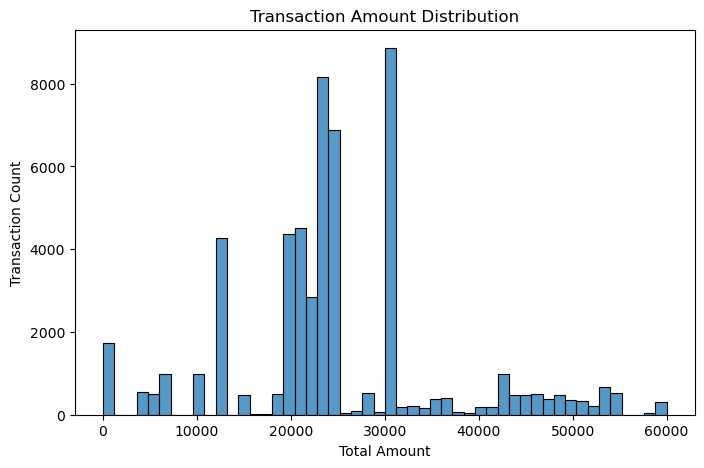

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    transactions["total_amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Transaction Count")

plt.show()

In [19]:
transactions["total_item"].describe()

count    53820.000000
mean         1.151486
std          0.358526
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: total_item, dtype: float64

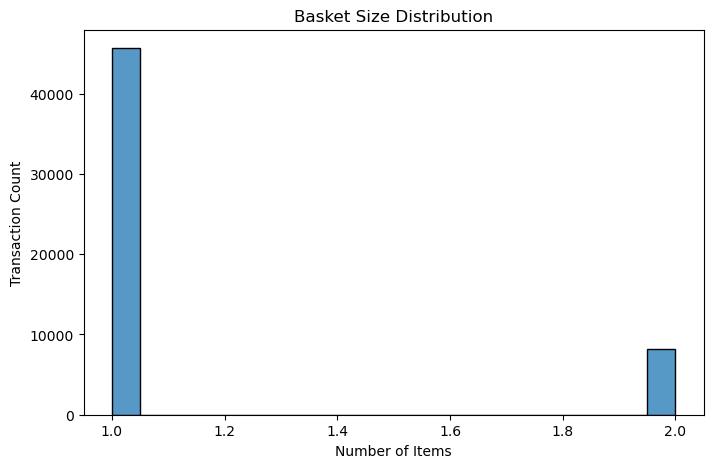

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    transactions["total_item"],
    bins=20
)

plt.title("Basket Size Distribution")
plt.xlabel("Number of Items")
plt.ylabel("Transaction Count")

plt.show()


## Findings — Basket Size Distribution

### Distribution behavior

The basket size distribution is highly concentrated around small transaction sizes.

Most transactions contain:

- 1 item

while a smaller number contain:

- 2 items

This suggests that the business is primarily driven by single-item purchases.

### Business interpretation

This behavior is consistent with café or beverage-focused F&B operations, where customers commonly purchase:

- a single drink,
- a single snack,
- or a small combination order.

The relatively small number of multi-item transactions suggests that larger baskets are less common.

### Implications for anomaly detection

The narrow basket-size distribution creates a strong baseline for identifying unusual ordering behavior.

Potential future anomaly candidates may include:

- unusually large basket sizes,
- abnormal multi-item transactions,
- operational bulk orders,
- or suspicious transaction patterns.

In [21]:
transactions["total_item"].value_counts().sort_index()

total_item
1    45667
2     8153
Name: count, dtype: int64

## Additional Findings — Basket Size Frequency

The basket size frequency analysis showed that transaction behavior is highly concentrated around very small basket sizes.

### Basket size frequencies

- 1 item:
  - 45,667 transactions
  - approximately 85% of all transactions

- 2 items:
  - 8,153 transactions
  - approximately 15% of all transactions

No larger basket sizes were observed in the dataset.

### Business interpretation

This strongly suggests that the business operates similarly to a café or beverage-focused F&B business where customers typically purchase:

- a single drink,
- a single food item,
- or a small two-item combination.

The dataset appears to represent highly standardized customer purchasing behavior.

### Implications for anomaly detection

Because normal basket behavior is tightly concentrated around 1–2 items, any future larger basket sizes would become highly unusual and potentially important for anomaly detection.

Examples of potential basket-size anomalies may include:

- unusually large orders,
- catering/group transactions,
- duplicated receipts,
- operational transactions,
- or data-quality issues.

In [22]:
transactions["outlet"].value_counts()

outlet
SHOP001    26250
SHOP003    16753
SHOP002    10817
Name: count, dtype: int64

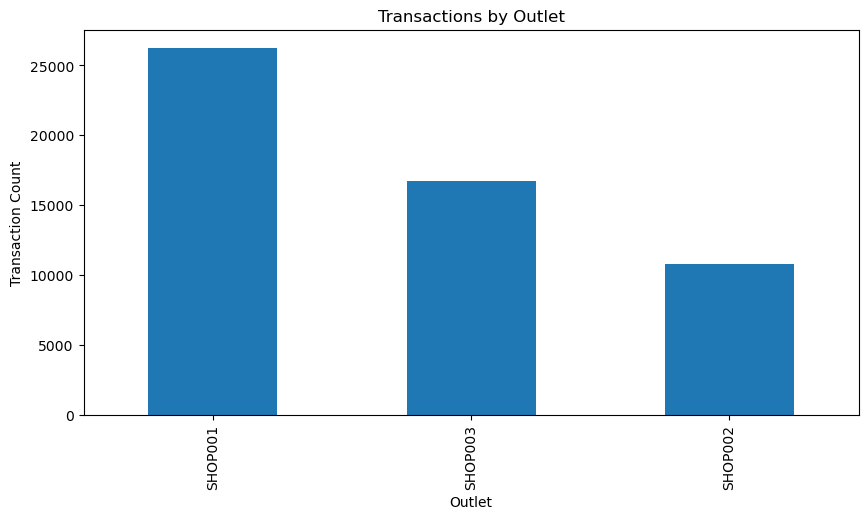

In [23]:
plt.figure(figsize=(10,5))

transactions["outlet"].value_counts().plot(
    kind="bar"
)

plt.title("Transactions by Outlet")
plt.xlabel("Outlet")
plt.ylabel("Transaction Count")

plt.show()

## Findings — Outlet Transaction Volume

The dataset contains transactions from three outlets:

- SHOP001
- SHOP002
- SHOP003

### Key observations

SHOP001 has the highest transaction volume with 26,250 transactions, representing approximately 48.8% of all transactions.

SHOP003 is the second busiest outlet with 16,753 transactions, representing approximately 31.1% of all transactions.

SHOP002 has the lowest transaction volume with 10,817 transactions, representing approximately 20.1% of all transactions.

### Business interpretation

The outlets do not have equal transaction volumes.

This may reflect differences in:

- outlet size,
- location,
- customer traffic,
- outlet age,
- operating conditions,
- or local demand.

At this stage, lower volume in SHOP002 should not be treated as an anomaly by itself. It is simply an outlet-level business pattern that needs to be considered during future analysis.

### Implications for anomaly detection

Anomaly detection should account for outlet-level differences.

A single global threshold may incorrectly flag normal behavior in smaller outlets as anomalous or miss abnormal behavior in larger outlets.

Therefore, future anomaly detection should compare each outlet against its own historical baseline where possible.

In [24]:
daily_transactions = (
    transactions
    .groupby("date")
    .size()
)

daily_transactions.describe()

count    272.000000
mean     197.867647
std       33.030526
min      126.000000
25%      174.000000
50%      194.000000
75%      220.000000
max      282.000000
dtype: float64

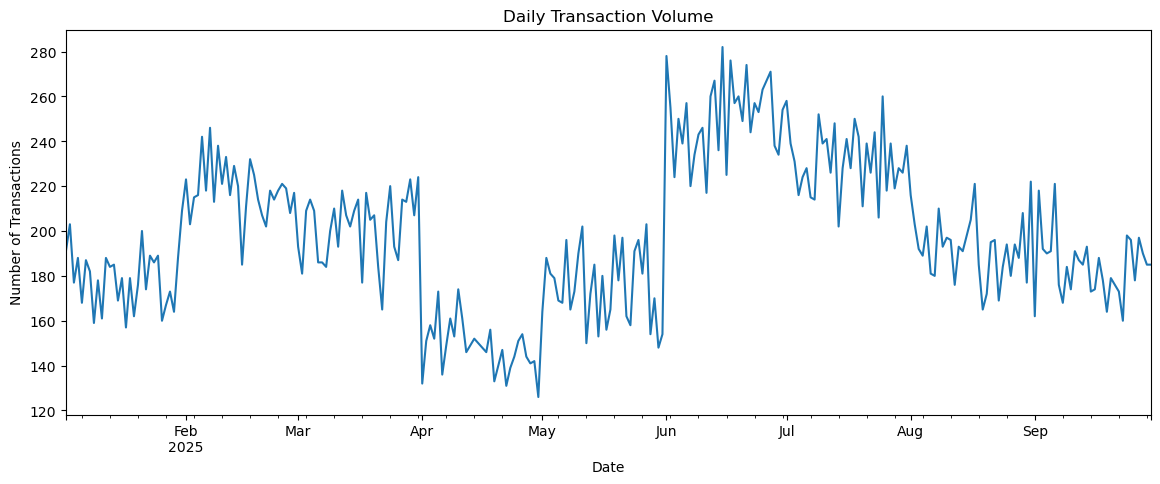

In [25]:
plt.figure(figsize=(14,5))

daily_transactions.plot()

plt.title("Daily Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.show()

## Findings — Daily Transaction Volume

The daily transaction volume analysis shows the total number of transactions per day across all outlets.

### Summary statistics

The dataset covers 272 transaction days.

The average daily transaction volume is approximately 198 transactions per day.

Most days fall between:

- 174 transactions/day at the 25th percentile
- 220 transactions/day at the 75th percentile

The lowest observed daily transaction count is 126, while the highest observed daily transaction count is 282.

### Time-based observations

The chart shows that transaction activity changes noticeably across the dataset period.

A lower-activity period appears around April, where daily transaction counts drop closer to the 130–160 range.

A higher-activity period appears around June and July, where daily transaction counts frequently rise above 230 and reach up to 282.

### Business interpretation

The changes in daily transaction volume may reflect real business conditions such as:

- seasonality,
- holiday effects,
- customer traffic changes,
- operational changes,
- outlet-level activity changes,
- or temporary disruptions.

At this stage, these patterns should be treated as candidates for further investigation, not confirmed anomalies.

### Implications for anomaly detection

This analysis confirms that time-based anomaly detection will be important.

Future anomaly detection should consider:

- rolling daily baselines,
- outlet-specific baselines,
- weekday patterns,
- month-level demand shifts,
- and sudden spikes or drops in transaction volume.

In [26]:
daily_revenue = (
    transactions
    .groupby("date")["total_amount"]
    .sum()
)

daily_revenue.describe()

count    2.720000e+02
mean     4.835574e+06
std      8.080915e+05
min      3.064000e+06
25%      4.234500e+06
50%      4.778500e+06
75%      5.413750e+06
max      7.007000e+06
Name: total_amount, dtype: float64

Text(0, 0.5, 'Total Revenue')

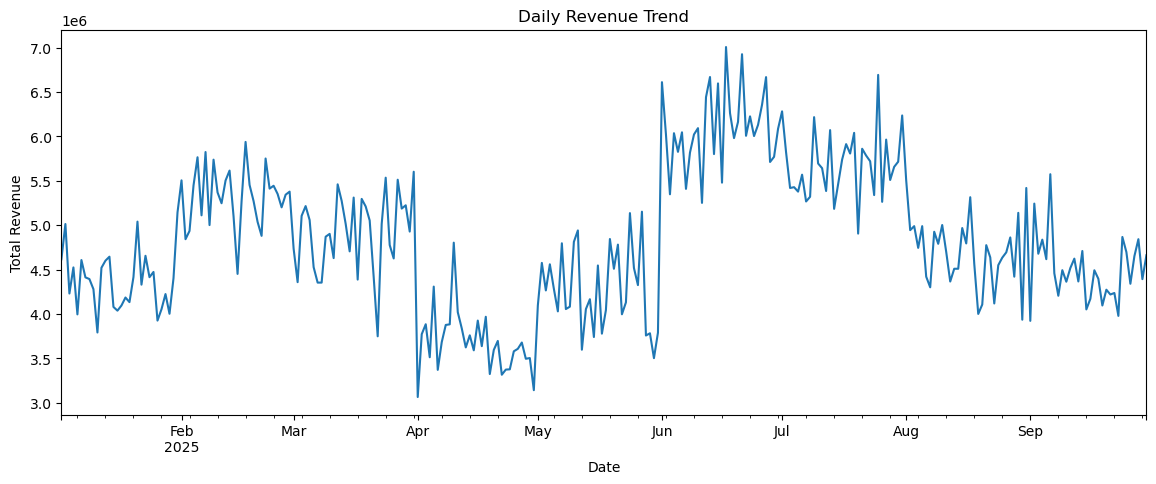

In [27]:
plt.figure(figsize=(14,5))

daily_revenue.plot()

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue")



## Findings — Daily Revenue Trend

The daily revenue trend shows a pattern similar to the daily transaction volume trend.

### Key observations

Revenue is lower around April, which aligns with the lower transaction volume observed during the same period.

Revenue increases strongly around June and July, which also aligns with the higher transaction volume during that period.

This suggests that daily revenue is closely related to daily transaction count.

### Business interpretation

The revenue changes appear to be mainly driven by transaction volume changes.

In other words:

- higher customer activity leads to higher revenue,
- lower customer activity leads to lower revenue.

At this stage, there is no clear evidence that revenue changes are mainly caused by changes in average transaction value.

### Implications for anomaly detection

Future anomaly detection should analyze both:

- daily transaction count,
- daily revenue.

It will also be useful to analyze average transaction value to determine whether revenue anomalies are caused by volume changes or by unusual spending behavior per transaction.

In [31]:
daily_avg_transaction_value = (
    transactions
    .groupby("date")["total_amount"]
    .mean()
)

daily_avg_transaction_value.describe()

count      272.000000
mean     24452.118936
std        833.940330
min      22231.638418
25%      23892.434988
50%      24419.183882
75%      24967.354508
max      27628.930818
Name: total_amount, dtype: float64

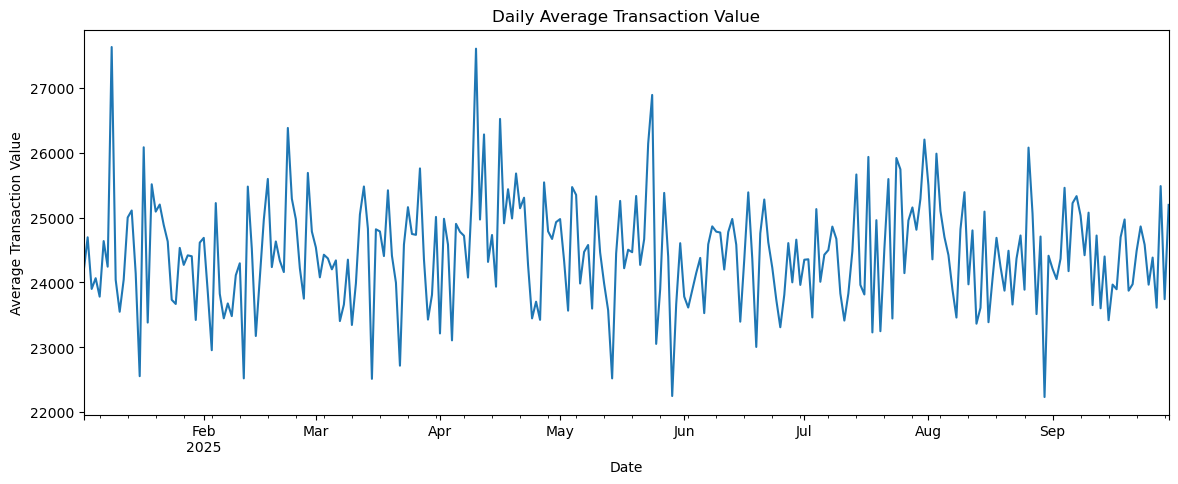

In [30]:
plt.figure(figsize=(14,5))

daily_avg_transaction_value.plot()

plt.title("Daily Average Transaction Value")
plt.xlabel("Date")
plt.ylabel("Average Transaction Value")

plt.show()

## Findings — Daily Average Transaction Value

The daily average transaction value was analyzed to understand whether daily revenue changes are driven by customer traffic or by changes in spending per transaction.

### Summary statistics

The average daily transaction value is approximately 24,452.

Most days fall within a relatively narrow range:

- 25th percentile: approximately 23,892
- median: approximately 24,419
- 75th percentile: approximately 24,967

The minimum observed daily average transaction value is approximately 22,232, while the maximum is approximately 27,629.

### Business interpretation

The daily average transaction value is relatively stable over time.

This suggests that changes in daily revenue are mainly driven by changes in transaction volume rather than major changes in customer spending per receipt.

In other words:

- high-revenue days are mostly caused by more transactions,
- low-revenue days are mostly caused by fewer transactions,
- average receipt value remains fairly consistent.

### Implications for anomaly detection

Daily transaction count is likely to be a strong signal for detecting abnormal business activity.

Daily revenue should also be monitored, but revenue anomalies may often be explained by changes in transaction volume.

Average transaction value can help identify cases where revenue changes are not explained by transaction count alone.

In [32]:
daily_transactions_by_outlet = (
    transactions
    .groupby(["date", "outlet"])
    .size()
    .reset_index(name="transaction_count")
)

daily_transactions_by_outlet.head()

,date,outlet,transaction_count
0,2025-01-02,SHOP001,82
1,2025-01-02,SHOP002,51
2,2025-01-02,SHOP003,58
3,2025-01-03,SHOP001,101
4,2025-01-03,SHOP002,26


In [33]:
daily_transactions_by_outlet_pivot = (
    daily_transactions_by_outlet
    .pivot(index="date", columns="outlet", values="transaction_count")
)

daily_transactions_by_outlet_pivot.describe()

outlet,SHOP001,SHOP002,SHOP003
count,272.000000,272.000000,272.000000
mean,96.507353,39.768382,61.591912
std,14.132476,11.619174,15.528536
min,66.000000,14.000000,21.000000
25%,86.000000,31.000000,54.000000
50%,95.500000,38.000000,63.000000
75%,105.000000,48.000000,72.000000
max,138.000000,71.000000,89.000000


Text(0.5, 1.0, 'Daily Transaction Volume by Outlet')

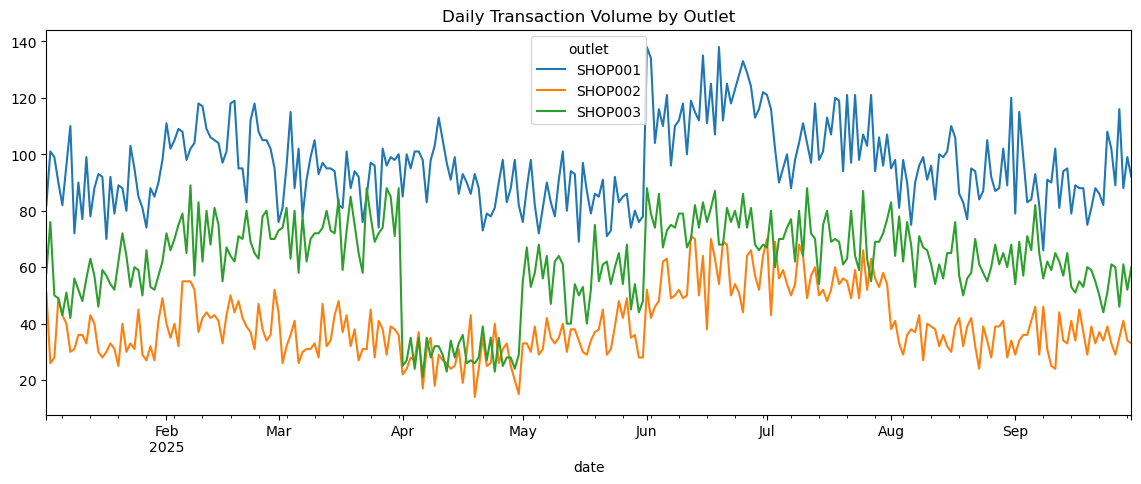

In [34]:
daily_transactions_by_outlet_pivot.plot(figsize=(14,5))

plt.title("Daily Transaction Volume by Outlet")

## Findings — Daily Transaction Volume by Outlet

Daily transaction volume was analyzed separately for each outlet.

### Outlet-level baselines

The three outlets have different daily transaction baselines:

- SHOP001 has the highest average daily transaction count at approximately 96.5 transactions/day.
- SHOP003 has the second-highest average daily transaction count at approximately 61.6 transactions/day.
- SHOP002 has the lowest average daily transaction count at approximately 39.8 transactions/day.

### Key observations

SHOP001 is consistently the busiest outlet, with daily transaction counts ranging from 66 to 138.

SHOP002 has the lowest transaction volume, with daily transaction counts ranging from 14 to 71.

SHOP003 sits between SHOP001 and SHOP002, with daily transaction counts ranging from 21 to 89.

The chart shows a visible drop around April across all outlets and a clear increase around June and July.

### Business interpretation

The outlet-level differences may reflect differences in:

- location,
- customer traffic,
- outlet size,
- operating conditions,
- or local demand.

The April drop appears across all outlets, suggesting that it may be caused by a business-wide or time-based factor rather than an issue in one specific outlet.

The June-July increase also appears across all outlets, suggesting a broader high-demand period.

### Implications for anomaly detection

Anomaly detection should account for outlet-level baselines.

A single global threshold may incorrectly flag normal behavior in smaller outlets as anomalous or fail to detect abnormal behavior in larger outlets.

Future anomaly detection should compare each outlet against its own historical behavior.

In [35]:
transactions["payment_method"].value_counts()

payment_method
BCA       42805
Cash      10913
GoFood      102
Name: count, dtype: int64

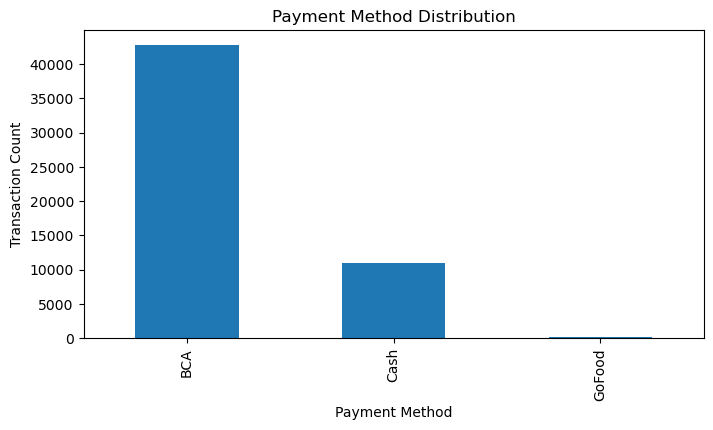

In [36]:
transactions["payment_method"].value_counts().plot(kind="bar", figsize=(8,4))

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Transaction Count")

plt.show()

In [37]:
transactions["use_loyalty_card"].value_counts()

use_loyalty_card
0    52087
1     1733
Name: count, dtype: int64

In [38]:
transactions["items"].value_counts().head(20)

items
Jus Semangka                            544
Friendly Coffee (Ice)                   539
Upgrade Beans (Arabica)                 538
Lemons                                  537
BLACK (Houseblend)                      527
Green Apple                             527
Shakencano                              524
Not Tiramisu Latte (Gedhe)              523
Creamy Klepon                           523
Jasmine (Hot)                           522
Sunset                                  521
Green Thai Tea (Gedhe)                  518
Friendly Coffee (Hot)                   517
Jasmine (Ice)                           514
Cappuccino (Hot Arabica)                513
Americano (Ice Houesblend)              510
Pisang Coklat                           507
Sitrus Cafe                             504
WHITE (Houseblend)                      503
Espresso Houseblend (Basic Espresso)    502
Name: count, dtype: int64

## Final Data Understanding Summary

This notebook explored the raw transaction and product datasets for the F&B sales anomaly detection project.

### Dataset structure

The transactions dataset contains 53,820 rows and 11 columns.

The products dataset contains 96 rows and 6 columns.

Each row in the transactions dataset represents one unique receipt-level transaction.

The `items` column contains one or more purchased products inside each receipt.

### Main findings

The dataset is receipt-level transaction data, not product-line-level data.

Most transaction amounts are concentrated between approximately 20,000 and 30,000.

The transaction amount distribution is right-skewed, with some higher-value receipts reaching 60,000.

There are 1,733 zero-value transactions where both `net_sales` and `total_amount` are zero.

Most transactions contain only one item, while a smaller number contain two items.

SHOP001 is the busiest outlet, followed by SHOP003 and SHOP002.

Daily revenue follows a similar trend to daily transaction volume.

Daily average transaction value is relatively stable, suggesting that daily revenue changes are mainly driven by transaction volume rather than changes in customer spending per receipt.

The three outlets have different daily transaction baselines, meaning future anomaly detection should compare each outlet against its own historical behavior.

BCA is the dominant payment method, followed by Cash, while GoFood appears rarely.

Only 1,733 transactions use a loyalty card, which matches the number of zero-value transactions and should be investigated further.

### Anomaly detection implications

The dataset is suitable for unsupervised sales anomaly detection.

Potential anomaly detection areas include:

- transaction-level value anomalies,
- zero-value transaction investigation,
- daily transaction volume anomalies,
- daily revenue anomalies,
- outlet-level anomalies,
- payment method anomalies,
- loyalty-card-related anomalies,
- and product-level anomalies after parsing the `items` column.

### Next notebook

The next notebook will be:

`02_data_preparation.ipynb`

The next phase will focus on preparing clean datasets for feature engineering and anomaly detection.

This will include:

- validating zero-value and loyalty-card transactions,
- checking transaction calculation consistency,
- handling data quality issues,
- preparing clean transaction-level data,
- parsing the `items` column,
- matching parsed items with product metadata,
- and creating daily outlet-level datasets for anomaly detection.